<a href="https://colab.research.google.com/github/gladysandr/dsga-celeratesschool-assignments/blob/main/Tugas_Asynchronous_4_DSGA_Gladys_Andromeda_Bilqis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUGAS CAMP BATCH 4 CELERATES SCHOOL**

**Data Science & Generative AI (DSGA)**

**Tugas Asynchronous 4: Applied Machine Learning**

Nama: Gladys Andromeda Bilqis

Mentor Personal: Hana Jatmiana

## **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

## **Data Understanding**

In [ ]:
# Load Dataset
df = pd.read_csv('/content/data.csv', na_values=['-9.0', '?'])

# Strip whitespace dari nama kolom
df.columns = df.columns.str.strip()

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'Kolom: {list(df.columns)}')

print('\n=== 10 Baris Pertama (data mentah) ===')
display(df.head(10))

Dataset berhasil dimuat!
Shape: (294, 14)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

=== 10 Baris Pertama (data mentah) ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,0
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0
5,32,0,2,105.0,198.0,0.0,0.0,165.0,0.0,0.0,NaN,NaN,NaN,0
6,32,1,2,110.0,225.0,0.0,0.0,184.0,0.0,0.0,NaN,NaN,NaN,0
7,32,1,2,125.0,254.0,0.0,0.0,155.0,0.0,0.0,NaN,NaN,NaN,0
8,33,1,3,120.0,298.0,0.0,0.0,185.0,0.0,0.0,NaN,NaN,NaN,0
9,34,0,2,130.0,161.0,0.0,0.0,190.0,0.0,0.0,NaN,NaN,NaN,0


## **Data Preprocessing**

In [ ]:
# Konversi semua kolom ke numerik
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('=== Info Dataset Setelah Konversi ===')
df.info()

# Cek missing values
print('\n=== Missing Values per Kolom (Sebelum Imputasi) ===')
print(df.isnull().sum())

# Handle missing values dengan median
df = df.fillna(df.median())

# Transform target jadi biner
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['num'])

display(df.head())

# Distribusi target
target_counts = df['target'].value_counts()
target_ratios = df['target'].value_counts(normalize=True) * 100

print('\n=== Distribusi Target ===')
for val, count in target_counts.items():
    label = 'Sakit Jantung (1)' if val == 1 else 'Tidak Sakit (0)'
    print(f"{label}: {count} pasien ({target_ratios[val]:.2f}%)")

=== Info Dataset Setelah Konversi ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  293 non-null    float64
 4   chol      271 non-null    float64
 5   fbs       286 non-null    float64
 6   restecg   293 non-null    float64
 7   thalach   293 non-null    float64
 8   exang     293 non-null    float64
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    float64
 11  ca        3 non-null      float64
 12  thal      28 non-null     float64
 13  num       294 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 32.3 KB

=== Missing Values per Kolom (Sebelum Imputasi) ===
age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,2.0,0.0,6.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,2.0,0.0,6.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,2.0,0.0,6.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,2.0,0.0,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,2.0,0.0,6.0,0



=== Distribusi Target ===
Tidak Sakit (0): 188 pasien (63.95%)
Sakit Jantung (1): 106 pasien (36.05%)


## **Data Splitting**

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data berhasil di-split!")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Data berhasil di-split!
Train: (235, 13), Test: (59, 13)


## **Handling Imbalanced Data (SMOTE)**

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nUkuran data latih sebelum SMOTE : {X_train.shape}")
print(f"Ukuran data latih sesudah SMOTE : {X_train_res.shape}")


Ukuran data latih sebelum SMOTE : (235, 13)
Ukuran data latih sesudah SMOTE : (300, 13)


## **Model Evaluation**

### **Naive Bayes**

=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.79      0.86        38
           1       0.70      0.90      0.79        21

    accuracy                           0.83        59
   macro avg       0.82      0.85      0.82        59
weighted avg       0.85      0.83      0.83        59



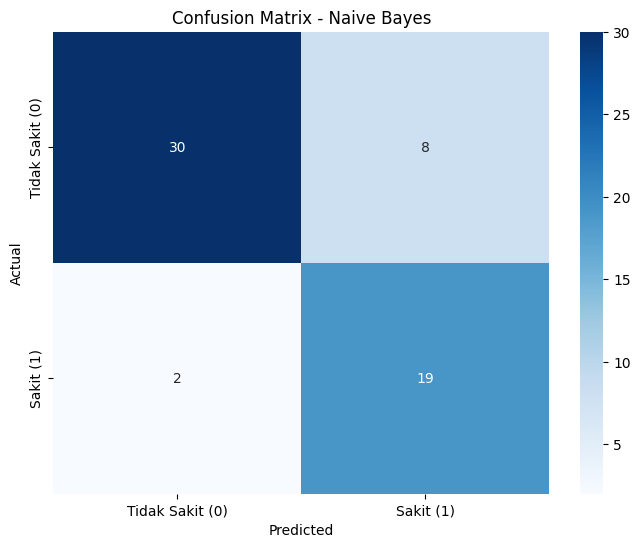

In [ ]:
# Inisialisasi dan Train Model Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_res, y_train_res)

# Prediksi
y_pred_nb = nb_model.predict(X_test)

# Evaluasi
print("=== Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_nb))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Sakit (0)', 'Sakit (1)'],
            yticklabels=['Tidak Sakit (0)', 'Sakit (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### **Random Forest**

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        38
           1       0.76      0.76      0.76        21

    accuracy                           0.83        59
   macro avg       0.82      0.82      0.82        59
weighted avg       0.83      0.83      0.83        59



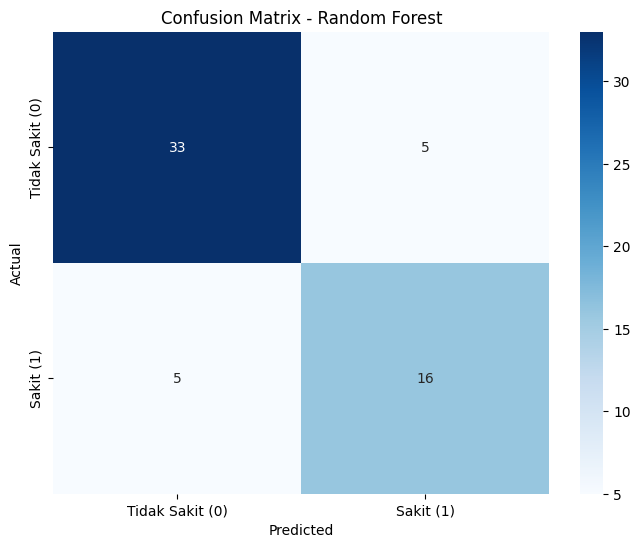

In [ ]:
# Inisialisasi dan Train Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

# Visualisasi Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Sakit (0)', 'Sakit (1)'],
            yticklabels=['Tidak Sakit (0)', 'Sakit (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### **Logistic Regression**

=== Logistic Regression Classification Report (Scaled Data) ===
              precision    recall  f1-score   support

           0       0.94      0.89      0.92        38
           1       0.83      0.90      0.86        21

    accuracy                           0.90        59
   macro avg       0.89      0.90      0.89        59
weighted avg       0.90      0.90      0.90        59



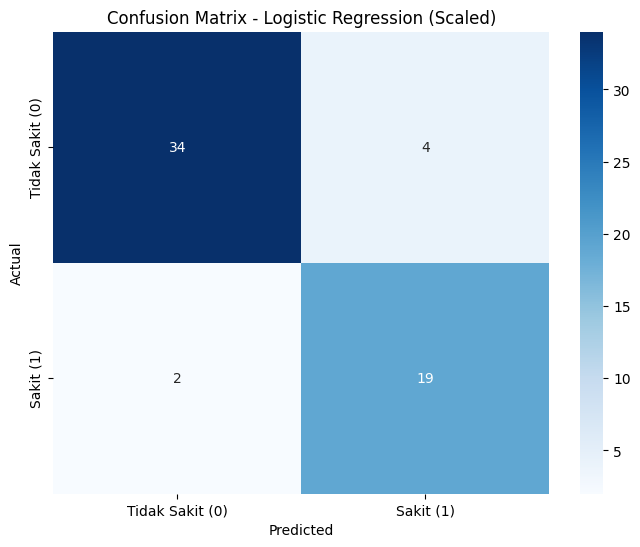

In [ ]:
# Scalling data untuk konvergensi Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Inisialisasi dan Train Model Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_res)

# Prediksi
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluasi
print("=== Logistic Regression Classification Report (Scaled Data) ===")
print(classification_report(y_test, y_pred_lr))

# Visualisasi Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
xticklabels=['Tidak Sakit (0)', 'Sakit (1)'],
yticklabels=['Tidak Sakit (0)', 'Sakit (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Scaled)')
plt.show()


### **Support Vector Machine**

=== Support Vector Machine Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.84      0.88        38
           1       0.75      0.86      0.80        21

    accuracy                           0.85        59
   macro avg       0.83      0.85      0.84        59
weighted avg       0.86      0.85      0.85        59



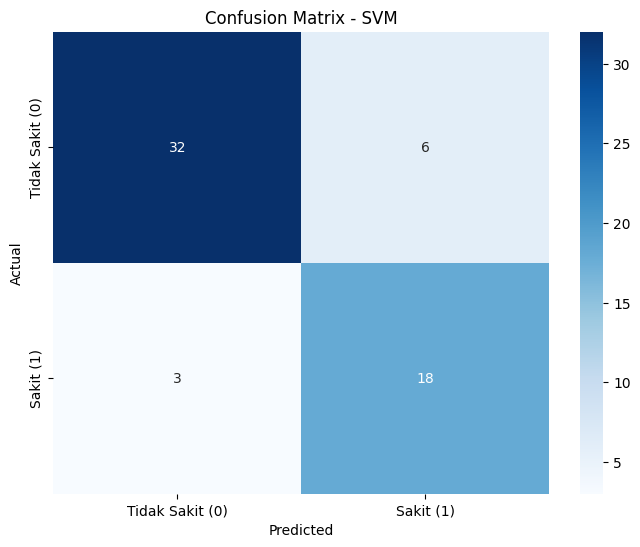

In [ ]:
# Inisialisasi dan Train Model SVM
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train_res)

# Prediksi
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluasi
print("=== Support Vector Machine Classification Report ===")
print(classification_report(y_test, y_pred_svm))

# Visualisasi Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Sakit (0)', 'Sakit (1)'],
            yticklabels=['Tidak Sakit (0)', 'Sakit (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

## **Model Comparison**

In [ ]:
# Menghitung metrik untuk setiap model
models = {
    'Naive Bayes': y_pred_nb,
    'Random Forest': y_pred_rf,
    'Logistic Regression': y_pred_lr,
    'SVM': y_pred_svm
}

performance_list = []

for name, pred in models.items():
    performance_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred)
    })

# DataFrame perbandingan
df_performance = pd.DataFrame(performance_list).sort_values(by='Accuracy', ascending=False)

print("=== Perbandingan Performa Model ===")
display(df_performance)

best_model = df_performance.iloc[0]['Model']
best_acc = df_performance.iloc[0]['Accuracy'] * 100

print(f"\nHasil Terbaik: {best_model} dengan Akurasi {best_acc:.2f}%")

=== Perbandingan Performa Model ===


,Model,Accuracy,Precision,Recall,F1-Score
2,Logistic Regression,0.898305,0.826087,0.904762,0.863636
3,SVM,0.847458,0.750000,0.857143,0.800000
1,Random Forest,0.830508,0.761905,0.761905,0.761905
0,Naive Bayes,0.830508,0.703704,0.904762,0.791667



Hasil Terbaik: Logistic Regression dengan Akurasi 89.83%
